In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import statsmodels.api as sm

plt.rcParams.update({'font.size': 14})

/home/users/rafaelox/nb_envs/climattr-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_736/138804022.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['log_obs'] = np.log(region_df['actual_cases'])
/tmp/ipykernel_736/138804022.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['log_pred'] = np.log(region_df['pred_cases'])
/home/users/rafaelox/nb_envs/clim

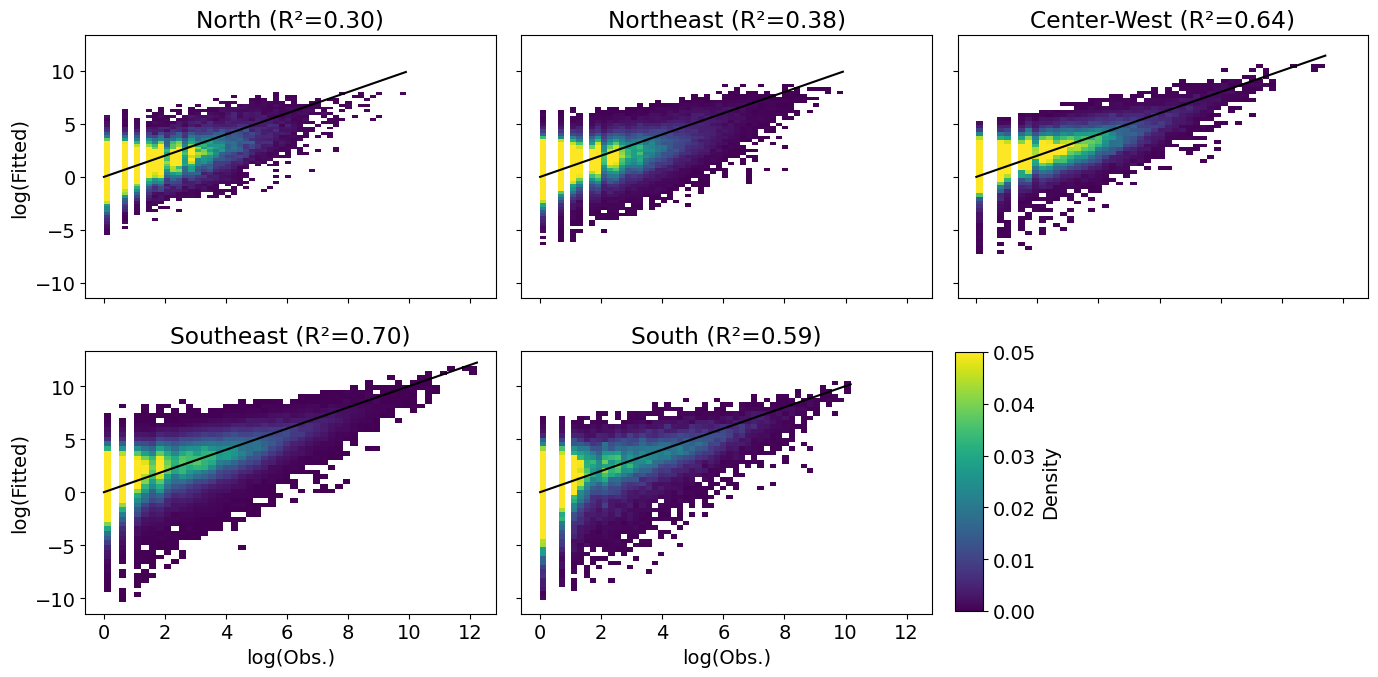

In [2]:
df = pd.read_csv('data/dengue_with_fitted_values.csv', parse_dates=['date_first_symptoms'])

fig, axarr = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)

for ax, region in zip(axarr.flatten(), ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']):
    region_df = df[df['region'] == region]

    region_df['log_obs'] = np.log(region_df['actual_cases'])
    region_df['log_pred'] = np.log(region_df['pred_cases'])

    region_df = region_df.dropna(subset=['log_obs', 'log_pred'])
    region_df = region_df[(region_df['actual_cases'] > 0)]

    reg = sm.OLS(region_df['log_obs'], sm.add_constant(region_df['log_obs'])).fit()
    region_df['fitted_line'] = reg.fittedvalues

    rsquared = region_df[['actual_cases', 'pred_cases']].corr().iloc[0, 1] ** 2

    plot = sns.histplot(region_df, x='log_obs', y='log_pred', ax=ax, cbar=False, bins=50, cmap='viridis', stat='density', vmin=0, vmax=0.05)
    region_df.sort_values('log_obs').plot(x='log_obs', y='fitted_line', ax=ax, color='k', legend=False)
    ax.set_title(f"{region if region != 'Middle-West' else 'Center-West'} (R²={rsquared:.2f})")
    ax.set_ylabel('log(Fitted)')
    ax.set_xlabel('log(Obs.)')

fig.delaxes(axarr[-1, -1])

cbar_ax = fig.add_axes([0.69, 0.11, 0.02, 0.37])
cbar = fig.colorbar(plot.collections[0], cax=cbar_ax)
cbar.set_label("Density")

plt.tight_layout()
plt.savefig('img/predicted_vs_observed_dengue_incidence.pdf', dpi=300, bbox_inches='tight')

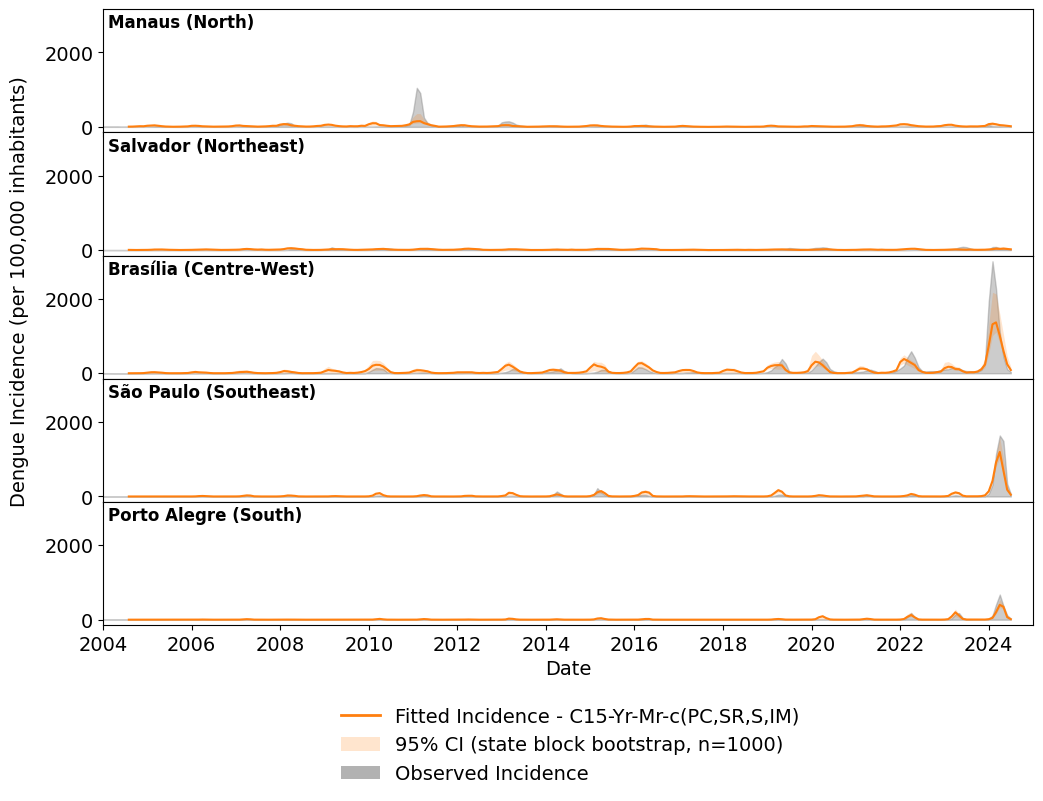

In [5]:
# One capital city per region, chosen as the largest capital in that region
capitals = {
    'AM_MANAUS': 'Manaus (North)',
    'BA_SALVADOR': 'Salvador (Northeast)',
    'DF_BRASILIA': 'Brasília (Centre-West)',
    'SP_SAO PAULO': 'São Paulo (Southeast)',
    'RS_PORTO ALEGRE': 'Porto Alegre (South)',
}

df = df[df['city_residency'].isin(capitals.keys())].copy()
df['actual_incidence'] = df['actual_cases'] / df['population'] * 1e5
df['city_label'] = df['city_residency'].map(capitals)

# 95% CI band from the state-block bootstrap refit (02_bootstrap_capital_incidence.R
# + 02_aggregate_capital_incidence_bootstrap.R) -- requires that job to have been run.
boot_summary = pd.read_csv(
    'data/statistics/dengue_capital_incidence_boot_summary.csv',
    parse_dates=['date_first_symptoms'],
    usecols=['city_residency', 'date_first_symptoms',
             'pred_capital_incidence_q025', 'pred_capital_incidence_q975'],
)
df = df.merge(boot_summary, on=['city_residency', 'date_first_symptoms'], how='left')

df = df.sort_values(['city_residency', 'date_first_symptoms'])

fig, axarr = plt.subplots(5, 1, figsize=(12, 8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0)

for ax, (city, label) in zip(axarr, capitals.items()):
    city_df = df[df['city_residency'] == city]

    ax.fill_between(
        city_df['date_first_symptoms'], 0, city_df['actual_incidence'],
        color='gray', alpha=0.4, label='Observed'
    )
    ax.fill_between(
        city_df['date_first_symptoms'],
        city_df['pred_capital_incidence_q025'], city_df['pred_capital_incidence_q975'],
        color='C1', alpha=0.2, linewidth=0, label='95% CI'
    )
    ax.plot(
        city_df['date_first_symptoms'], city_df['pred_incidence'],
        color='C1', linewidth=1.5, label='Fitted'
    )

    ax.text(0.005, 0.85, label, transform=ax.transAxes, fontsize=12, fontweight='bold')

ax.set_xlabel('Date')
ax.text(-0.1, 1, 'Dengue Incidence (per 100,000 inhabitants)', rotation=90, transform=ax.transAxes)
ax.set_xlim([pd.to_datetime('2004-01-01'), pd.to_datetime('2024-12-31')])

# ---- LEGEND ----
legend_elements = [
    Line2D([0], [0], color='C1', lw=2, label='Fitted Incidence - C15-Yr-Mr-c(PC,SR,S,IM)'),
    Patch(facecolor='C1', alpha=0.2, label='95% CI (state block bootstrap, n=1000)'),
    Patch(facecolor='k', alpha=0.3, label='Observed Incidence'),
]
fig.legend(handles=legend_elements, frameon=False, ncol=1, bbox_to_anchor=(0.72, 0.03))


plt.savefig('img/figureS_capital_timeseries.pdf', dpi=300, bbox_inches='tight')


In [9]:
city_df

,city_residency,year,date_first_symptoms,mean_2m_air_temp_degree1,mean_2m_air_temp_degree1_lag1,mean_2m_air_temp_degree1_lag2,mean_2m_air_temp_degree1_lag3,mean_2m_air_temp_degree1_lag4,mean_2m_air_temp_degree1_lag5,mean_2m_air_temp_degree2_lag1,...,temp_bs_lag52,temp_bs_lag53,temp_bs_lag54,pred_incidence,pred_cases,actual_cases,actual_incidence,city_label,pred_capital_incidence_q025,pred_capital_incidence_q975
720,RS_PORTO ALEGRE,year_2005South,2004-08-01,14.929893,13.448347,15.580798,15.821874,22.536942,23.147265,180.858034,...,0.484447,0.339902,0.000000e+00,0.029035,0.410030,0,0.000000,Porto Alegre (South),0.004885,0.053259
721,RS_PORTO ALEGRE,year_2005South,2004-09-01,18.437410,14.929893,13.448347,15.580798,15.821874,22.536942,222.901712,...,0.490935,0.301597,0.000000e+00,0.021026,0.296933,1,0.070812,Porto Alegre (South),0.004664,0.079349
722,RS_PORTO ALEGRE,year_2005South,2004-10-01,18.457517,18.437410,14.929893,13.448347,15.580798,15.821874,339.938081,...,0.296462,0.050905,0.000000e+00,0.011877,0.167725,0,0.000000,Porto Alegre (South),0.002810,0.050330
723,RS_PORTO ALEGRE,year_2005South,2004-11-01,20.801710,18.457517,18.437410,14.929893,13.448347,15.580798,340.679949,...,0.284440,0.046594,0.000000e+00,0.011603,0.163864,0,0.000000,Porto Alegre (South),0.002992,0.051807
724,RS_PORTO ALEGRE,year_2005South,2004-12-01,23.079485,20.801710,18.457517,18.437410,14.929893,13.448347,432.711149,...,0.177476,0.018519,0.000000e+00,0.018948,0.267576,0,0.000000,Porto Alegre (South),0.004030,0.052809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,RS_PORTO ALEGRE,year_2024South,2024-03-01,24.277793,26.003669,24.273425,24.428665,21.181612,18.827955,676.190782,...,0.428509,0.128721,0.000000e+00,150.247669,2236.063937,6002,403.291916,Porto Alegre (South),138.365569,309.420894
956,RS_PORTO ALEGRE,year_2024South,2024-04-01,21.650944,24.277793,26.003669,24.273425,24.428665,21.181612,589.411254,...,0.486417,0.227056,0.000000e+00,325.223321,4840.142586,10030,673.945004,Porto Alegre (South),306.019695,543.118725
957,RS_PORTO ALEGRE,year_2024South,2024-05-01,16.491909,21.650944,24.277793,26.003669,24.273425,24.428665,468.763377,...,0.451122,0.430575,1.564548e-05,287.608464,4280.338719,5489,368.821947,Porto Alegre (South),268.343544,396.769382
958,RS_PORTO ALEGRE,year_2024South,2024-06-01,17.063726,16.491909,21.650944,24.277793,26.003669,24.273425,271.983053,...,0.456666,0.418842,5.628439e-07,53.152524,791.043495,1769,118.864278,Porto Alegre (South),51.897103,91.962392
